# 🏥 MedAssist AI — Notebook 05: Evaluation V6.0

## Version History
| Version | Changes |
|---------|--------|
| V6.0 | CNN+ViT soft-voting ensemble (CNN-only fallback), TTA×8, meta_mask in Dataset & eval loop, SkinLesionDataset searches PAD+ISIC+MCR dirs |
| V5.0 | SWA checkpoint, per-class thresholds, TTA×8, confusion matrix, ROC curves |
| V4.2 | Basic evaluation |

## Purpose
- Load SWA CNN model (required) + optional ViT model
- Soft-voting ensemble: CNN 60% + ViT 40% (CNN-only if ViT absent)
- Test-Time Augmentation (TTA × 8)
- Compute Macro F1, per-class metrics, confusion matrix, ROC curves
- Save all results to Google Drive

## CELL 0 — Environment Setup & Imports

In [3]:
#!/usr/bin/env python3
"""
MedAssist AI — 05 Evaluation V6.0
Final Evaluation Notebook with Test-Time Augmentation (TTA) and Threshold Optimization
"""

from google.colab import drive
try:
    drive.mount('/content/drive')
except Exception:
    print('Drive already mounted.')

import subprocess, sys
for pkg in ['mlflow', 'timm', 'albumentations', 'transformers', 'scikit-learn', 'seaborn']:
    try:
        __import__(pkg if pkg != 'scikit-learn' else 'sklearn')
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

import os, json, warnings, glob, time
import numpy as np
import pandas as pd
import cv2
import matplotlib
matplotlib.use('inline')
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import f1_score, classification_report, confusion_matrix, roc_curve, auc, precision_recall_fscore_support
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
torch.backends.cudnn.benchmark = True

VERSION = 'V6.0'
BASE_PATH = '/content/drive/MyDrive/MedAssist_AI'
DATASET_PATH = os.path.join(BASE_PATH, 'dataset')
PROCESSED_PATH = os.path.join(BASE_PATH, 'data', 'processed')
MODELS_PATH = os.path.join(BASE_PATH, 'models')
RESULTS_PATH = os.path.join(BASE_PATH, 'results')

for p in [MODELS_PATH, RESULTS_PATH]:
    os.makedirs(p, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('=' * 60)
print(f'  MedAssist AI — Final Evaluation {VERSION} (Ensemble CNN+ViT)')
print(f'  Device: {device} | PyTorch: {torch.__version__}')
print('=' * 60)
DRIVE_DATASET = '/content/drive/MyDrive/MedAssist_AI/dataset'
PAD_ZIP       = '/content/drive/MyDrive/MedAssist_AI/dataset/images.zip'
ISIC_ZIP      = '/content/drive/MyDrive/MedAssist_AI/dataset_isic2019/isic_2019_images.zip'
MCR_ZIP       = '/content/drive/MyDrive/MedAssist_AI/dataset_mcr_sl/mcr_sl_images.zip'
LOCAL_DATASET = '/content/local_dataset'
LOCAL_IMAGES  = '/content/local_dataset/images'
LOCAL_ISIC    = '/content/local_dataset/isic2019'
LOCAL_MCR     = '/content/local_dataset/mcr_sl'
import zipfile, gc
from tqdm.auto import tqdm


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  MedAssist AI — Final Evaluation V6.0 (Ensemble CNN+ViT)
  Device: cuda | PyTorch: 2.11.0+cu128


## CELL 1 — SSD Optimization: Copy All Datasets to Local NVMe

In [4]:
def stream_extract_zip(zip_path, dest_dir, batch_size=500, label='Dataset'):
    """Extract zip DIRECTLY from Drive to SSD — no cp, no temp file.
    Reads from Drive mount → writes to Colab SSD one file at a time.
    Resumes automatically (skips files already on SSD).
    """
    os.makedirs(dest_dir, exist_ok=True)
    existing = set(os.listdir(dest_dir)) if os.path.isdir(dest_dir) else set()

    with zipfile.ZipFile(zip_path, 'r') as zf:
        members = [m for m in zf.namelist()
                   if not m.endswith('/') and os.path.basename(m)]
        to_extract = [m for m in members if os.path.basename(m) not in existing]

        if not to_extract:
            print(f'  ✅ {label}: all {len(existing):,} files already on SSD — skipping')
            return len(existing)

        print(f'  📦 {label}: extracting {len(to_extract):,}/{len(members):,} files '
              f'(resuming {len(existing):,} already done)...')

        for i, member in enumerate(tqdm(to_extract, desc=f'{label} → SSD')):
            data = zf.read(member)
            fname = os.path.basename(member)
            with open(os.path.join(dest_dir, fname), 'wb') as f:
                f.write(data)
            del data
            if (i + 1) % batch_size == 0:
                gc.collect()

    gc.collect()
    n_final = len(os.listdir(dest_dir))
    print(f'  ✅ {label}: {n_final:,} files ready at {dest_dir}')
    return n_final

print('=' * 60)
print('  ⚡ Copying datasets to local SSD — run every session!')
print('=' * 60)

# PAD-UFES-20
if os.path.isdir(LOCAL_IMAGES) and len(os.listdir(LOCAL_IMAGES)) >= 2000:
    print(f'  ✅ PAD-UFES-20: already on SSD ({len(os.listdir(LOCAL_IMAGES)):,} files)')
elif os.path.exists(PAD_ZIP):
    stream_extract_zip(PAD_ZIP, LOCAL_IMAGES, batch_size=500, label='PAD-UFES-20')
else:
    print(f'  ⚠️  PAD-UFES-20: zip not found — skipping')

# ISIC 2019
if os.path.isdir(LOCAL_ISIC) and len(os.listdir(LOCAL_ISIC)) >= 2000:
    print(f'  ✅ ISIC 2019: already on SSD ({len(os.listdir(LOCAL_ISIC)):,} files)')
elif os.path.exists(ISIC_ZIP):
    stream_extract_zip(ISIC_ZIP, LOCAL_ISIC, batch_size=300, label='ISIC 2019')
else:
    print(f'  ⚠️  ISIC 2019: zip not found — run 00_setup first')

# MCR-SL  (threshold 2000 because total = 2,131 clinical + dermoscopic)
if os.path.isdir(LOCAL_MCR) and len(os.listdir(LOCAL_MCR)) >= 2000:
    print(f'  ✅ MCR-SL: already on SSD ({len(os.listdir(LOCAL_MCR)):,} files)')
elif os.path.exists(MCR_ZIP):
    stream_extract_zip(MCR_ZIP, LOCAL_MCR, batch_size=300, label='MCR-SL')
else:
    print(f'  ⚠️  MCR-SL: zip not found — run 00_setup first')

images_dir = LOCAL_IMAGES
if not os.path.isdir(images_dir) or not os.listdir(images_dir):
    print('WARNING: local SSD not found, falling back to Drive...')
    images_dir = os.path.join(DATASET_PATH, 'images')
print(f'PAD-UFES-20 ready at: {images_dir}')
print(f'ISIC 2019 ready at:   {LOCAL_ISIC} (exists={os.path.isdir(LOCAL_ISIC)})')
print(f'MCR-SL ready at:      {LOCAL_MCR} (exists={os.path.isdir(LOCAL_MCR)})')
# ============================================================
# Load Configuration and Resources
# ============================================================

  ⚡ Copying datasets to local SSD — run every session!
  ✅ PAD-UFES-20: already on SSD (2,298 files)
  ✅ ISIC 2019: already on SSD (25,331 files)
  📦 MCR-SL: extracting 1,833/2,131 files (resuming 298 already done)...


MCR-SL → SSD:   0%|          | 0/1833 [00:00<?, ?it/s]

  ✅ MCR-SL: 2,131 files ready at /content/local_dataset/mcr_sl
PAD-UFES-20 ready at: /content/local_dataset/images
ISIC 2019 ready at:   /content/local_dataset/isic2019 (exists=True)
MCR-SL ready at:      /content/local_dataset/mcr_sl (exists=True)


## CELL 2 — Load Configuration and Resources

In [5]:
with open(os.path.join(PROCESSED_PATH, 'preprocessing_config.json'), 'r') as f:
    config = json.load(f)
assert config['version'] == 'V6.0'

NUM_CLASSES = config['num_classes']
NUM_META = config['num_meta_features']
CLASS_NAMES = config['class_names']
IMG_SIZE = config['img_size']
SELECTED_FEATS = config['selected_features']
NORM_MEAN = config['normalization']['mean']
NORM_STD = config['normalization']['std']

print(f'Config V6.0: {NUM_META} features, {NUM_CLASSES} classes, img={IMG_SIZE}')

# Load thresholds — من 04b إذا موجود، وإلا raw probs
thresholds_path = os.path.join(MODELS_PATH, 'thresholds_V6.0.json')
if os.path.exists(thresholds_path):
    with open(thresholds_path, 'r') as f:
        thresholds_dict = json.load(f)
    thresholds = np.array([thresholds_dict[c] for c in CLASS_NAMES])
    print(f'✅ Loaded optimized thresholds from 04b:')
    for c, t in thresholds_dict.items():
        print(f' {c}: {t:.4f}')
else:
    thresholds = np.ones(NUM_CLASSES)
    thresholds_dict = {c: 1.0 for c in CLASS_NAMES}
    print('⚠️ thresholds_V6.0.json not found — using raw probs')
    print(f' Expected at: {thresholds_path}')
# ============================================================
# Preprocessing and Dataset
# ============================================================

Config V6.0: 7 features, 6 classes, img=256
✅ Loaded optimized thresholds from 04b:
 ACK: 0.7000
 BCC: 0.4750
 MEL: 0.7500
 NEV: 0.2000
 SCC: 0.8000
 SEK: 0.6000


## CELL 3 — Preprocessing Functions (Shades-of-Gray + DullRazor)

In [6]:
def shades_of_gray(img, power=6):
    img_f = img.astype(np.float32) + 1e-7
    if power == -1:
        norm = np.max(img_f, axis=(0, 1))
    else:
        norm = np.power(np.mean(np.power(img_f, power), axis=(0, 1)), 1.0 / power)
    norm = norm + 1e-7
    result = img_f / norm * np.mean(norm)
    return np.clip(result, 0, 255).astype(np.uint8)

def dullrazor_hair_removal(img, kernel_size=17, threshold=10):
    """Optimized DullRazor hair removal (FAST)."""
    # 1. Find the hair
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_size, kernel_size))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, hair_mask = cv2.threshold(blackhat, threshold, 255, cv2.THRESH_BINARY)

    # 2. FAST INPAINTING: Create a blurred version of the image
    # and only replace the exact pixels where the hair mask is true.
    blurred_img = cv2.medianBlur(img, 15) # Fast median filter

    # Expand mask to 3 channels so it matches the image shape
    hair_mask_3d = np.expand_dims(hair_mask, axis=-1)

    # Where mask is white (hair), use blurred background. Otherwise, use original.
    result = np.where(hair_mask_3d > 0, blurred_img, img)

    return result.astype(np.uint8)
val_transforms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.CLAHE(clip_limit=2.0, p=1.0),
    A.Normalize(mean=NORM_MEAN, std=NORM_STD),
    ToTensorV2()
])


## CELL 4 — Test Dataset (SkinLesionDataset with meta_mask)

In [7]:
class SkinLesionDataset(Dataset):
    """V6.0 Dataset — searches PAD-UFES-20 + ISIC 2019 + MCR-SL image dirs."""

    def __init__(self, df, images_dir, metadata_cols, transform=None):
        self.df = df.reset_index(drop=True)
        self.images_dir = images_dir
        self.transform = transform
        self.metadata_cols = metadata_cols
        self.img_paths = {}

        # PAD-UFES-20: nested subdirs
        for sub in ['imgs_part_1/imgs_part_1','imgs_part_2/imgs_part_2','imgs_part_3/imgs_part_3']:
            full_dir = os.path.join(images_dir, sub)
            if os.path.isdir(full_dir):
                for fname in os.listdir(full_dir):
                    if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                        self.img_paths[fname] = os.path.join(full_dir, fname)
        # PAD-UFES-20: flat directory
        if os.path.isdir(images_dir):
            for fname in os.listdir(images_dir):
                if fname.lower().endswith(('.png', '.jpg', '.jpeg')) and fname not in self.img_paths:
                    self.img_paths[fname] = os.path.join(images_dir, fname)

        # ISIC 2019: /content/local_dataset/isic2019/
        isic_dir = '/content/local_dataset/isic2019'
        if os.path.isdir(isic_dir):
            for fname in os.listdir(isic_dir):
                if fname.lower().endswith(('.png', '.jpg', '.jpeg')) and fname not in self.img_paths:
                    self.img_paths[fname] = os.path.join(isic_dir, fname)

        # MCR-SL: /content/local_dataset/mcr_sl/
        mcr_dir = '/content/local_dataset/mcr_sl'
        if os.path.isdir(mcr_dir):
            for fname in os.listdir(mcr_dir):
                if fname.lower().endswith(('.png', '.jpg', '.jpeg')) and fname not in self.img_paths:
                    self.img_paths[fname] = os.path.join(mcr_dir, fname)

        missing = [f for f in df['img_filename'].values if f not in self.img_paths]
        if missing:
            print(f'⚠️  WARNING: {len(missing)} images not found! Dropping them from dataset. First 5: {missing[:5]}')
            missing_set = set(missing)
            self.df = self.df[~self.df['img_filename'].isin(missing_set)].reset_index(drop=True)
        else:
            print(f'✅ All {len(self.df)} images found ({len(self.img_paths):,} total in lookup)')

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_filename = row['img_filename']

        CACHE_DIR = '/content/fast_images'
        cache_path = os.path.join(CACHE_DIR, img_filename)

        if not os.path.exists(cache_path):
            # Graceful fallback: preprocess on-the-fly from raw SSD path
            raw_path = self.img_paths.get(img_filename)
            if raw_path is None or not os.path.exists(raw_path):
                raise FileNotFoundError(
                    f"Image not found in cache OR raw SSD: {img_filename}. "
                    f"Re-run CELL 1 (SSD extract) then CELL 6 (Pre-cache)."
                )
            img = cv2.imread(raw_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (256, 256), interpolation=cv2.INTER_AREA)
            img = shades_of_gray(img, power=6)
            img = dullrazor_hair_removal(img, kernel_size=17, threshold=10)
            os.makedirs(CACHE_DIR, exist_ok=True)
            cv2.imwrite(cache_path, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
        else:
            img = cv2.imread(cache_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transform:
            img = self.transform(image=img)['image']

        meta  = torch.FloatTensor(row[self.metadata_cols].values.astype(float))
        label = int(row['label'])

        # meta_mask: ones for PAD-UFES (complete clinical data), partial for ISIC
        clinical_ok = bool(row.get('clinical_complete', True))
        if clinical_ok:
            meta_mask = torch.ones(len(self.metadata_cols), dtype=torch.float32)
        else:
            # ISIC-2019: only age and gender are available
            meta_mask = torch.tensor([1, 1, 0, 0, 0, 0, 0], dtype=torch.float32)

        return img, meta, meta_mask, label, img_filename


test_df = pd.read_csv(os.path.join(PROCESSED_PATH, 'test.csv'))
test_dataset = SkinLesionDataset(test_df, images_dir, SELECTED_FEATS, val_transforms)
BATCH_SIZE = 64
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True, prefetch_factor=2
)
print(f'Test loader: {len(test_loader)} batches ({len(test_dataset)} samples)')
print(f'Test dataset: {len(test_dataset)} samples | meta_mask: enabled')
##Cell 5.5 Pre-Cache Cell


✅ All 654 images found (29,760 total in lookup)
Test loader: 11 batches (654 samples)
Test dataset: 654 samples | meta_mask: enabled


## CELL 5 — Pre-Cache Cell (Run at Every Session Start)

In [8]:
assert 'test_dataset' in globals(), "❌ Run CELL 5 (DataLoaders) first before pre-caching!"
import concurrent.futures
from tqdm.auto import tqdm
import cv2
import os

CACHE_DIR = '/content/fast_images'
os.makedirs(CACHE_DIR, exist_ok=True)

def process_and_cache(args):
    img_filename, img_path = args
    cache_path = os.path.join(CACHE_DIR, img_filename)

    # Skip if already done (makes restarting instant)
    if os.path.exists(cache_path):
        return 'skip'

    img = cv2.imread(img_path)
    if img is None:
        return 'fail'

    # Pre-resize to 256x256 first. This reduces pixel operations by up to 16x,
    # making preprocessing (Shades of Gray, DullRazor) and disk writes extremely fast.
    img = cv2.resize(img, (256, 256), interpolation=cv2.INTER_AREA)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = shades_of_gray(img, power=6)
    img = dullrazor_hair_removal(img, kernel_size=17, threshold=10)

    cv2.imwrite(cache_path, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
    return 'ok'

# Gather only the specific images needed by the active datasets to avoid caching all 29k+ images
all_items = []
needed_filenames = set()

if 'train_df' in globals():
    needed_filenames.update(train_df['img_filename'].dropna().tolist())
elif 'train_dataset' in globals():
    needed_filenames.update(train_dataset.df['img_filename'].dropna().tolist())

if 'val_df' in globals():
    needed_filenames.update(val_df['img_filename'].dropna().tolist())
elif 'val_dataset' in globals():
    needed_filenames.update(val_dataset.df['img_filename'].dropna().tolist())

if 'test_df' in globals():
    needed_filenames.update(test_df['img_filename'].dropna().tolist())
elif 'test_dataset' in globals():
    needed_filenames.update(test_dataset.df['img_filename'].dropna().tolist())

for f in needed_filenames:
    path = None
    if 'train_dataset' in globals() and f in train_dataset.img_paths:
        path = train_dataset.img_paths[f]
    elif 'val_dataset' in globals() and f in val_dataset.img_paths:
        path = val_dataset.img_paths[f]
    elif 'test_dataset' in globals() and f in test_dataset.img_paths:
        path = test_dataset.img_paths[f]

    if path:
        all_items.append((f, path))

if all_items:
    print(f'Starting cache for {len(all_items)} images...')
    with concurrent.futures.ThreadPoolExecutor(max_workers=4) as executor:
        results = list(tqdm(executor.map(process_and_cache, all_items), total=len(all_items), desc='Caching images to SSD'))
    counts = {k: results.count(k) for k in ['ok', 'skip', 'fail']}
    print(f'Cache complete: {counts}')
else:
    print('No datasets found to cache.')
# ============================================================
# Model Architecture (EXACT match to 04a/04b)
# ============================================================

Starting cache for 654 images...


Caching images to SSD:   0%|          | 0/654 [00:00<?, ?it/s]

Cache complete: {'ok': 654, 'skip': 0, 'fail': 0}


## CELL 6 — Model Architecture V6.0 (GatedCrossAttentionFusion)

In [9]:
class WeightedFocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.5, label_smoothing=0.05):
        super().__init__()
        self.gamma = gamma
        self.label_smoothing = label_smoothing
        if alpha is not None:
            self.register_buffer('alpha', torch.tensor(alpha, dtype=torch.float32))
        else:
            self.alpha = None

    def forward(self, logits, targets):
        num_classes = logits.size(-1)
        log_probs = F.log_softmax(logits, dim=-1)
        probs = torch.exp(log_probs)

        pt = probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        focal_weight = (1 - pt) ** self.gamma

        if self.label_smoothing > 0:
            smooth = self.label_smoothing / (num_classes - 1)
            log_pt = log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)
            ce = -(1.0 - self.label_smoothing) * log_pt \
                 - smooth * log_probs.sum(dim=-1)
        else:
            ce = F.nll_loss(log_probs, targets, reduction='none')

        loss = focal_weight * ce

        if self.alpha is not None:
            alpha_t = self.alpha.gather(0, targets)
            loss = alpha_t * loss

        return loss.mean()

class GeM(nn.Module):
    """Generalized Mean Pooling — أفضل من AvgPool في medical imaging."""
    def __init__(self, p: float = 3.0, eps: float = 1e-6):
        super().__init__()
        self.p   = nn.Parameter(torch.tensor(p, dtype=torch.float32))
        self.eps = eps
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return F.avg_pool2d(
            x.clamp(min=self.eps).pow(self.p),
            (x.size(-2), x.size(-1))
        ).pow(1.0 / self.p)

class ImageBranch(nn.Module):
    def __init__(self, num_classes=6, embed_dim=256, backbone_name='efficientnet_b3'):
        super().__init__()
        self.backbone_name = backbone_name
        self.backbone = timm.create_model(backbone_name, pretrained=False, num_classes=0, global_pool='')
        backbone_dim = self.backbone.num_features
        self.projection = nn.Sequential(
            nn.Conv2d(backbone_dim, 512, 1), nn.BatchNorm2d(512), nn.GELU(),
            nn.Conv2d(512, embed_dim, 1), nn.BatchNorm2d(embed_dim),
        )
        self.auxiliary_head = nn.Sequential(
            GeM(p=3.0), nn.Flatten(),          # ✅ إصلاح
            nn.Linear(backbone_dim, 256), nn.GELU(), nn.Dropout(0.3), nn.Linear(256, num_classes)
        )
        self.pool = nn.AdaptiveAvgPool2d(7)
        self.embed_dim = embed_dim

    def forward(self, x):
        features = self.backbone(x)
        if 'swin' in self.backbone_name:
            if features.dim() == 3: # (B, L, C) -> (B, C, H, W)
                B, L, C = features.shape
                H = W = int(math.sqrt(L))
                features = features.transpose(1, 2).view(B, C, H, W)
            elif features.dim() == 4 and features.shape[1] == features.shape[2]: # (B, H, W, C)
                features = features.permute(0, 3, 1, 2)

        aux_logits = self.auxiliary_head(features)
        pooled = self.pool(features)
        projected = self.projection(pooled)
        B, C, H, W = projected.shape
        patches = projected.view(B, C, H*W).permute(0, 2, 1)
        return patches, aux_logits, features

class MLPBranch(nn.Module):
    def __init__(self, num_features=7, embed_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(num_features, 128), nn.LayerNorm(128), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(128, 64), nn.LayerNorm(64), nn.GELU(), nn.Dropout(0.35),
            nn.Linear(64, embed_dim),
        )
    def forward(self, x, meta_mask=None):
        if meta_mask is not None:
            x = x * meta_mask.float()
        return self.net(x)

class GatedCrossAttentionFusion(nn.Module):
    def __init__(self, img_embed_dim=256, meta_embed_dim=64, num_classes=6, num_heads=4):
        super().__init__()
        self.embed_dim = img_embed_dim
        self.meta_proj = nn.Sequential(nn.Linear(meta_embed_dim, img_embed_dim), nn.LayerNorm(img_embed_dim))
        self.img_norm = nn.LayerNorm(img_embed_dim)
        self.pos_embed = nn.Parameter(torch.zeros(1, 49, img_embed_dim))
        self.cross_attn = nn.MultiheadAttention(embed_dim=img_embed_dim, num_heads=num_heads, dropout=0.1, batch_first=True)
        self.img_global_pool_proj = nn.Sequential(nn.Linear(img_embed_dim, img_embed_dim), nn.LayerNorm(img_embed_dim))
        self.gate = nn.Sequential(nn.Linear(img_embed_dim * 2, img_embed_dim), nn.Sigmoid())
        self.classifier = nn.Sequential(
            nn.Linear(img_embed_dim, 256), nn.LayerNorm(256), nn.GELU(), nn.Dropout(0.55),
            nn.Linear(256, 128), nn.LayerNorm(128), nn.GELU(), nn.Dropout(0.45),
            nn.Linear(128, num_classes)
        )

    def forward(self, patches, meta_emb):
        meta_q = self.meta_proj(meta_emb).unsqueeze(1)
        patches_norm = self.img_norm(patches + self.pos_embed)
        attended, _ = self.cross_attn(meta_q, patches_norm, patches_norm)
        attended = attended.squeeze(1)
        img_global = patches.mean(dim=1)
        img_global = self.img_global_pool_proj(img_global)
        gate_input = torch.cat([attended, img_global], dim=-1)
        g = self.gate(gate_input)
        fused = g * attended + (1 - g) * img_global
        logits = self.classifier(fused)
        return logits, g.unsqueeze(1)

class MedAssistModel(nn.Module):
    def __init__(self, num_meta=7, num_classes=6, img_embed_dim=256, meta_embed_dim=64, backbone_name='efficientnet_b3'):
        super().__init__()
        self.image_branch = ImageBranch(num_classes=num_classes, embed_dim=img_embed_dim, backbone_name=backbone_name)
        self.mlp_branch = MLPBranch(num_features=num_meta, embed_dim=meta_embed_dim)
        self.fusion = GatedCrossAttentionFusion(img_embed_dim, meta_embed_dim, num_classes, num_heads=4)
    def forward(self, images, metadata, meta_mask=None):
        patches, aux_logits, _ = self.image_branch(images)
        meta_emb = self.mlp_branch(metadata, meta_mask)
        main_logits, gate = self.fusion(patches, meta_emb)
        return main_logits, aux_logits, gate

## CELL 7 — Load Checkpoints & Ensemble Setup

In [10]:
# Load CNN model (required)
cnn_model = MedAssistModel(num_meta=NUM_META, num_classes=NUM_CLASSES, backbone_name='efficientnet_b3').to(device)
cnn_path = os.path.join(MODELS_PATH, 'swa_model_V6.0.pth')
print(f'Loading CNN model from {cnn_path}')
assert os.path.exists(cnn_path), f'❌ CNN model not found: {cnn_path}. Run 04b first.'
cnn_model.load_state_dict(torch.load(cnn_path, map_location=device))
cnn_model.eval()
print('✅ CNN model loaded')

# Load ViT model (optional — falls back to CNN-only if missing)
vit_path = os.path.join(MODELS_PATH, 'swa_model_vit_V6.0.pth')
USE_ENSEMBLE = os.path.exists(vit_path)
if USE_ENSEMBLE:
    vit_model = MedAssistModel(num_meta=NUM_META, num_classes=NUM_CLASSES, backbone_name='swin_tiny_patch4_window7_224').to(device)
    vit_model.load_state_dict(torch.load(vit_path, map_location=device))
    vit_model.eval()
    print('✅ ViT model loaded — Soft-Voting Ensemble (CNN 60% + ViT 40%) enabled')
else:
    vit_model = None
    print('⚠️ ViT model not found — using CNN-only mode (100% CNN)')
# ============================================================

Loading CNN model from /content/drive/MyDrive/MedAssist_AI/models/swa_model_V6.0.pth
✅ CNN model loaded
⚠️ ViT model not found — using CNN-only mode (100% CNN)


## CELL 8 — TTA Augmentation Definitions

In [11]:
# TTA Definitions
# ============================================================
def apply_tta(images):
    """Generate 8 augmentations for a batch of images."""
    B, C, H, W = images.shape
    aug_list = []

    # 1. Original
    aug_list.append(images)

    # 2. Horizontal Flip
    aug_list.append(torch.flip(images, dims=[3]))

    # 3. Vertical Flip
    aug_list.append(torch.flip(images, dims=[2]))

    # 4. H-Flip + V-Flip
    aug_list.append(torch.flip(images, dims=[2, 3]))

    # 5. Rotate 90
    aug_list.append(torch.rot90(images, k=1, dims=[2, 3]))

    # 6. Rotate 180
    aug_list.append(torch.rot90(images, k=2, dims=[2, 3]))

    # 7. Rotate 270
    aug_list.append(torch.rot90(images, k=3, dims=[2, 3]))

    # 8. Center Crop 224x224 then resize to 256x256
    crop_size = 224
    start = (H - crop_size) // 2
    cropped = images[:, :, start:start+crop_size, start:start+crop_size]
    resized = F.interpolate(cropped, size=(H, W), mode='bilinear', align_corners=False)
    aug_list.append(resized)

    return aug_list
# ============================================================

## CELL 9 — Evaluation Loop (TTA × 8 + Ensemble + meta_mask)

In [12]:
# Evaluation Loop
# ============================================================
print('\n' + '=' * 60)
print('  RUNNING EVALUATION ON TEST SET (with TTA x8)')
print('=' * 60)

all_probs = []
all_labels = []
all_filenames = []

with torch.no_grad():
    for images, meta, meta_mask, labels, filenames in tqdm(test_loader, desc='Testing'):
        images    = images.to(device, non_blocking=True)
        meta      = meta.to(device, non_blocking=True)
        meta_mask = meta_mask.to(device, non_blocking=True)

        # Get 8 augmentations
        images_tta = apply_tta(images)

        batch_probs = torch.zeros((images.size(0), NUM_CLASSES), device=device)

        for aug_img in images_tta:
            with autocast():
                cnn_logits, _, _ = cnn_model(aug_img, meta, meta_mask)
                cnn_probs = F.softmax(cnn_logits, dim=-1)
                if USE_ENSEMBLE:
                    vit_logits, _, _ = vit_model(aug_img, meta, meta_mask)
                    vit_probs = F.softmax(vit_logits, dim=-1)
                    probs = 0.6 * cnn_probs + 0.4 * vit_probs
                else:
                    probs = cnn_probs
                batch_probs += probs

        # Average probabilities over 8 augs
        batch_probs /= 8.0

        all_probs.append(batch_probs.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_filenames.extend(filenames)

all_probs = np.concatenate(all_probs, axis=0)
all_labels = np.array(all_labels)
# ============================================================


  RUNNING EVALUATION ON TEST SET (with TTA x8)


Testing:   0%|          | 0/11 [00:00<?, ?it/s]

## CELL 10 — Compute Metrics, Visualizations & Save Results

Applying per-class optimized thresholds...

--- Final Test Metrics ---
Macro F1 Score: 0.7315

Classification Report:
              precision    recall  f1-score   support

         ACK     0.7049    0.6615    0.6825       130
         BCC     0.8100    0.8804    0.8438        92
         MEL     0.7547    0.6154    0.6780        65
         NEV     0.7282    0.9530    0.8256       149
         SCC     0.6824    0.6444    0.6629        90
         SEK     0.7980    0.6172    0.6960       128

    accuracy                         0.7431       654
   macro avg     0.7464    0.7287    0.7315       654
weighted avg     0.7451    0.7431    0.7373       654



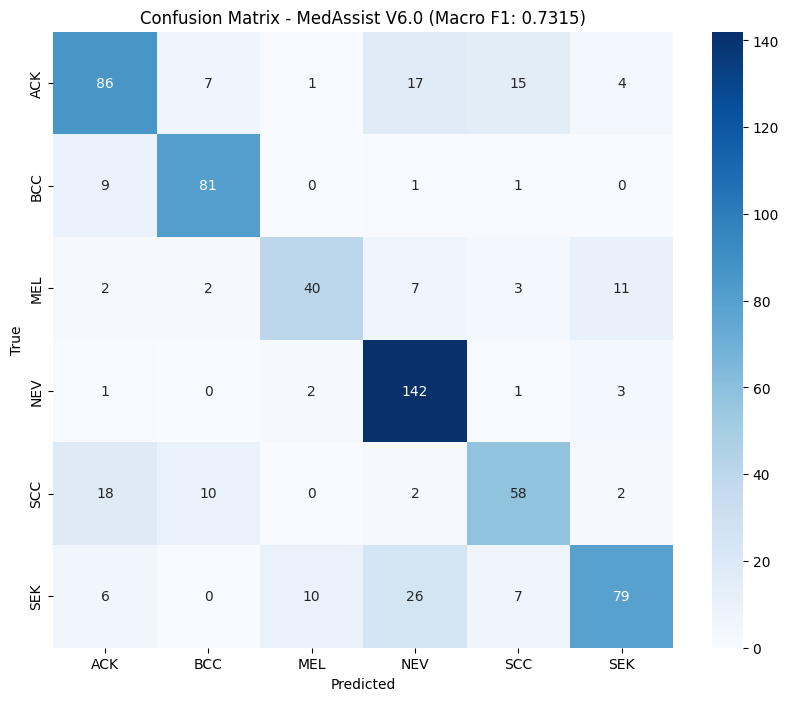


  EVALUATION COMPLETE
  Saved files in /content/drive/MyDrive/MedAssist_AI/results:
    - confusion_matrix_V6.0.png
    - roc_curves_V6.0.png
    - classification_report_V6.0.txt
    - evaluation_results_V6.0.json
    - test_predictions_V6.0.csv


In [13]:
# Apply Per-Class Threshold Optimization
# ============================================================
print('Applying per-class optimized thresholds...')
adjusted_probs = all_probs.copy()
for c in range(NUM_CLASSES):
    adjusted_probs[:, c] = adjusted_probs[:, c] / thresholds[c]

# The prediction is the class with the highest adjusted probability
predictions = adjusted_probs.argmax(axis=1)   # ✅ إصلاح: adjusted وليس raw

# ============================================================
# Compute Metrics
# ============================================================
macro_f1 = f1_score(all_labels, predictions, average='macro', zero_division=0)
precision, recall, f1_per_class, _ = precision_recall_fscore_support(all_labels, predictions, labels=range(NUM_CLASSES))

print('\n--- Final Test Metrics ---')
print(f'Macro F1 Score: {macro_f1:.4f}')

clf_report_str = classification_report(all_labels, predictions, target_names=CLASS_NAMES, digits=4)
print('\nClassification Report:')
print(clf_report_str)

results_dict = {
    'version': VERSION,
    'macro_f1': float(macro_f1),
    'per_class_f1': {CLASS_NAMES[i]: float(f1_per_class[i]) for i in range(NUM_CLASSES)},
    'per_class_precision': {CLASS_NAMES[i]: float(precision[i]) for i in range(NUM_CLASSES)},
    'per_class_recall': {CLASS_NAMES[i]: float(recall[i]) for i in range(NUM_CLASSES)},
    'thresholds_used': thresholds_dict
}

# ============================================================
# Visualizations
# ============================================================
# 1. Confusion Matrix
from IPython.display import display
cm = confusion_matrix(all_labels, predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f'Confusion Matrix - MedAssist V6.0 (Macro F1: {macro_f1:.4f})')
plt.xlabel('Predicted')
plt.ylabel('True')
cm_path = os.path.join(RESULTS_PATH, 'confusion_matrix_V6.0.png')
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()

# 2. ROC Curves per class
plt.figure(figsize=(12, 10))
for i in range(NUM_CLASSES):
    y_true_binary = (all_labels == i).astype(int)
    y_scores = all_probs[:, i]  # Use original probabilities for ROC, not adjusted
    fpr, tpr, _ = roc_curve(y_true_binary, y_scores)
    roc_auc = auc(fpr, tpr)

    plt.subplot(2, 3, i + 1)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve: {CLASS_NAMES[i]}')
    plt.legend(loc="lower right")

plt.tight_layout()
roc_path = os.path.join(RESULTS_PATH, 'roc_curves_V6.0.png')
plt.savefig(roc_path, dpi=150, bbox_inches='tight')
plt.close()

# ============================================================
# Save Results
# ============================================================
# Save classification report txt
clf_report_path = os.path.join(RESULTS_PATH, 'classification_report_V6.0.txt')
with open(clf_report_path, 'w') as f:
    f.write(clf_report_str)

# Save JSON metrics
json_path = os.path.join(RESULTS_PATH, 'evaluation_results_V6.0.json')
with open(json_path, 'w') as f:
    json.dump(results_dict, f, indent=2)

# Save predictions CSV
df_preds = pd.DataFrame({
    'img_filename': all_filenames,
    'true_label': [CLASS_NAMES[l] for l in all_labels],
    'pred_label': [CLASS_NAMES[p] for p in predictions]
})
for i, c in enumerate(CLASS_NAMES):
    df_preds[f'prob_{c}'] = all_probs[:, i]
for i, c in enumerate(CLASS_NAMES):
    df_preds[f'adj_prob_{c}'] = adjusted_probs[:, i]

preds_path = os.path.join(RESULTS_PATH, 'test_predictions_V6.0.csv')
df_preds.to_csv(preds_path, index=False)

print('\n' + '=' * 60)
print('  EVALUATION COMPLETE')
print('=' * 60)
print(f'  Saved files in {RESULTS_PATH}:')
print(f'    - confusion_matrix_V6.0.png')
print(f'    - roc_curves_V6.0.png')
print(f'    - classification_report_V6.0.txt')
print(f'    - evaluation_results_V6.0.json')
print(f'    - test_predictions_V6.0.csv')
print('=' * 60)